<a href="https://colab.research.google.com/github/nightsky18/Aprendizaje-de-maquinas/blob/main/Cuaderno_1_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Importación de librerias**
### **Conexión con el entorno:**
- **From google.colab import drive**  Permite que la máquina virtual de Google Colab acceda a los archivos almacenados a la cuenta de Google Drive.
### **Librería de Machine Learning**
- **Scikit-learn** es la librería principal para Machine Learning clásico en Python.
  - El módulo **datasets** contiene conjuntos de datos de prueba.
  - El módulo **preprocessing** contiene funciones para el Data Cleaning y transformación.
### **Procesamiento Numérico y Tabular:**
- **Numpy** maneja arreglos multidimensionales y álgebra lineal. Los modelos de Machine Learning matemáticamente solo entienden matrices de números.
- **Pandas** está construida sobre Numpy. Permite manejar datos en forma de tablas estructuradas (DataFrames), lo que facilita la lectura de archivos .csv, filtrado, cruce y agrupación de datos.

### **Visualización de datos**
- **Matplotlib** es la librería base --> requiere mucho código para gráficos detallados.
- **Seaborn** está construida sobre Matplotlib; simplifica la creación de gráficos estadísticos (como mapas de calor o distribuciones) usando menos líneas de código.



In [2]:
from google.colab import drive # Para importar desde drive
from sklearn import datasets
from sklearn import preprocessing  #herramientas para limpiar/preparar datos
import numpy as np # Para el algebra lineal (Operar matrices, vectores)
import pandas as pd # Manejar df
import matplotlib.pyplot as plt
import seaborn as sns #para gráficas -- se complementa con matplot



### **Instalación de paquetes externos:**
- **! :** le indica a Google Colab que la línea no es código Python, sino un comando directo para el sistema operativo subyacente (Linux).

- **pip install** es el gestor que descarga e instala la librería phik desde los repositorios oficiales de Python.

### **Importación de módulos para importación:**
- **plot_correlation_matrix** trae una función específica diseñada para dibujar la matriz de resultados de forma visual y entendible.

In [3]:
!pip install phik
import phik
from phik import resources
from phik.report import plot_correlation_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 7.5 MB/s eta 0:00:00


### **Importación para entrenamiento**

- Se importa la función train_test_split, que sirve para dividir un conjunto de datos en subgrupos.



In [56]:
from sklearn.model_selection import train_test_split  # permite crear sub grupos de entrenamiento

#### **Importación del Modelo de Machine Learning**
- Se importa el algoritmo "K-Nearest Neighbors" (K-Vecinos Más Cercanos, o KNN para abreviar) desde la librería Scikit-Learn.
- Se importan módulos específicos del submódulo metrics (métricas) de Scikit-Learn.

  - confusion_matrix: Es una función matemática que cruza las predicciones del modelo con las respuestas reales.
  - ConfusionMatrixDisplay: Es una herramienta para dibujar esa matriz matemáticamente calculada para que se vea bonita y con colores.
  - classification_report: Genera un resumen estadístico escrito con métricas de rendimiento (como precisión y sensibilidad).

- Se importa el algoritmo GaussianNB (Naive Bayes bajo distribución Gaussiana) de la librería Scikit-Learn.

- Se importa el algoritmo SVC (Clasificador de Vectores de Soporte), que es la implementación matemática de Scikit-Learn para las famosas Máquinas de Vectores de Soporte (SVM).

- Se importa la función matemática que calcula la precisión (Exactitud)
- Se importa la clase GridSearchCV (Búsqueda en Cuadrícula con Validación Cruzada) de Scikit-Learn.






In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn import metrics

from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from sklearn.model_selection import GridSearchCV


### **Conectando Google Drive**
- el método **mount** de la librería drive. Crea una ruta virtual (/content/drive) en la máquina de Colab que apunta directamente al almacenamiento en la nube.

### **Definiendo los nombres de las columnas (Metadatos)**
- Se crea una lista estándar de Python (entre corchetes []) que contiene 5 strings.
Estos son los nombres estandarizados para el dataset Iris (longitud y ancho del sépalo y pétalo, y la clase o especie de la flor).

    **Nota:** este CSV específico no tiene encabezados, se necesitas darle esta lista a Pandas para que sepa cómo llamar a cada columna
### **Carga y visualización del archivo en un DataFrame (Tabla):**
- Se usa la función **read_csv** de Pandas.
- El primer argumento es la ruta exacta donde se guardó el archivo en  Drive.
- **names = colums:** usa la lista que se acaba de crear como los títulos de las columnas".
- **header=None:** Es una instrucción de seguridad que confirma a Pandas que el archivo original no tiene una fila de títulos.
- Todo este resultado se guarda en una variable llamada **df_data**
- **df_data** Al colocar el nombre de la variable al final de la celda, Colab imprime automáticamente la representación visual de la tabla.


In [4]:
drive.mount('/content/drive')
colums = ['sepal_lenght', 'sepal_width', 'petal_lenght', 'petal_width', 'class']  #Crea una lista con los 5 nombres de las columnas del dataset Iris, porque el csv no tiene encabezados
df_data = pd.read_csv('/content/drive/MyDrive/Aprendizaje de máquinas/iris.csv', names = colums, header=None)
df_data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,sepal_lenght,sepal_width,petal_lenght,petal_width,class
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
146,6.7,3.0,5.2,2.3,Iris-virginica
147,6.3,2.5,5.0,1.9,Iris-virginica
148,6.5,3.0,5.2,2.0,Iris-virginica
149,6.2,3.4,5.4,2.3,Iris-virginica


*Muestra las 5 columnas con los nombres que se definieron  (sepal_lenght, etc.) y las primeras y últimas 5 filas de los datos*

##**Análisis exploratorio de los datos**

### **Inicio de los datos**
- La primera fila de un dataset suele mostrar cómo se registraron los datos originalmente. Si no  se pone ningún número entre los paréntesis **df_data.head()**, Pandas mostrará por defecto las primeras 5 filas.

### **Datos al azar**
-  El método **sample()** extrae una muestra aleatoria del dataset. En este caso, 4 filas al azar.

### **El final de los datos**
- **tail():** Extrae las últimas filas del archivo; en este caso, las últimas 2.

In [5]:

df_data.head(10) #Muestra las primeras 10 filas del DataFrame (por defecto son 5).
#df_data.sample(4) #Muestra 4 filas ALEATORIAS
#df_data.tail(2) #Muestra las últimas 2 filas


,sepal_lenght,sepal_width,petal_lenght,petal_width,class
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
6,5.4,3.9,1.7,0.4,Iris-setosa
7,4.6,3.4,1.4,0.3,Iris-setosa
8,5.0,3.4,1.5,0.2,Iris-setosa
9,4.4,2.9,1.4,0.2,Iris-setosa
10,4.9,3.1,1.5,0.1,Iris-setosa


### **Distribución de clases**
- Esta instrucción toma la columna class del DataFrame y cuenta cuántas veces aparece cada valor distinto.
   
   Esto es importante porque en muchos problemas de Machine Learning, sobre todo de clasificación, conviene saber si el dataset está:
    - Balanceado: cuando las clases tienen cantidades parecidas o iguales.
    - Desbalanceado: cuando una clase aparece muchísimo más que otra.

  *Si un dataset está muy desbalanceado, el modelo puede aprender mal y favorecer la clase mayoritaria.*

In [6]:
# Cuenta cuántas veces aparece cada valor único // dataset balancedos-- cantidad de datos iguales
df_data['class'].value_counts()

,count
class,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


*Que esté balanceado es una buena señal porque:*
- el modelo tendrá ejemplos suficientes de cada clase;
- no habrá una clase “dominando” el aprendizaje;
- la evaluación del modelo suele ser más justa y clara.

### **Visualización gráfica de datos**
#### **Gráfico de barras**
-  Se llama a la librería **Matplotlib** (alias plt) y se usa la función **figure**. El parámetro figsize recibe una tupla (ancho, alto) medida en pulgadas.
- Se llama a la librería **Seaborn** y se usa la función **countplot** que  es la versión visual de value_counts().Automáticamente se agrupan los datos iguales y levanta una barra por cada categoría

<Axes: xlabel='count', ylabel='class'>

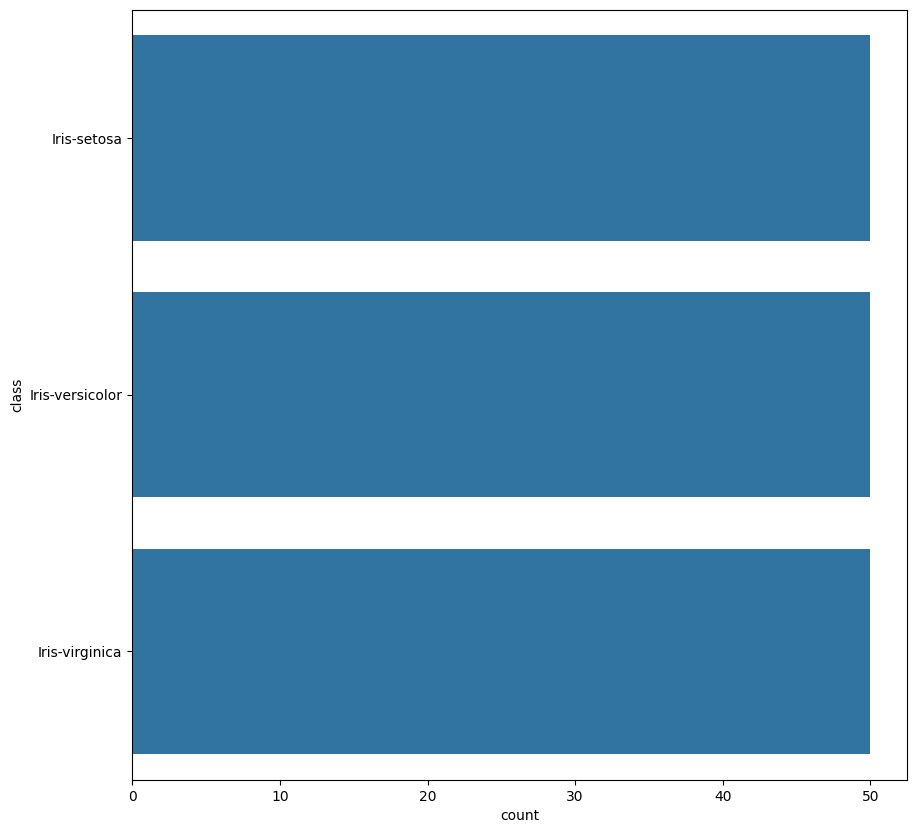

In [7]:
plt.figure(figsize=(10, 10)) #Crea un lienzo vacío de 10x10 pulgadas
sns.countplot(df_data['class'])


#### **Gráfico de pastel**
- **df_data['class'].value_counts()** --> genera los números absolutos (50, 50, 50). *plt.pie()* toma estos números, suma el total (150) y calcula matemáticamente qué ángulo del círculo le corresponde a cada número.

- **labels=df_data['class'].unique: ()** --> unique() es un método de Pandas que extrae una lista sin repeticiones de los nombres que hay en la columna ( ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']).

  ***Nota: .unique() extrae los nombres en el orden en que aparecen por primera vez en el archivo. Si el archivo no está ordenado perfectamente, las etiquetas no coincidirán con los números.***

  *Forma correcta y más segura de escribirlo:* ***labels=df_data['class'].value_counts().index***
  
  *(Esto garantiza que la etiqueta correcta se pegue al número correcto)*
- **autopct='%.2f%%':** auto-percentage es el comando que dibuja los números encima del color. El texto %.2f%% es un formato clásico del lenguaje C que Python heredó:
  - %: Indica que empieza un formato.
  - .2f: Significa "Float (número decimal) con 2 decimales".
  - %%: Dibuja el símbolo literal de porcentaje "%" al final del número.


([<matplotlib.patches.Wedge at 0x7f96fd15b9e0>,
 [Text(0.5499999722395388, 0.9526279601903919, 'Iris-setosa'),
  Text(-1.0999999999999959, -9.616505800409723e-08, 'Iris-versicolor'),
  Text(0.5500003659264657, -0.9526277328950455, 'Iris-virginica')],
 [Text(0.29999998485793017, 0.5196152510129409, '33.33%'),
  Text(-0.5999999999999978, -5.2453668002234845e-08, '33.33%'),
  Text(0.30000019959625396, -0.5196151270336611, '33.33%')])

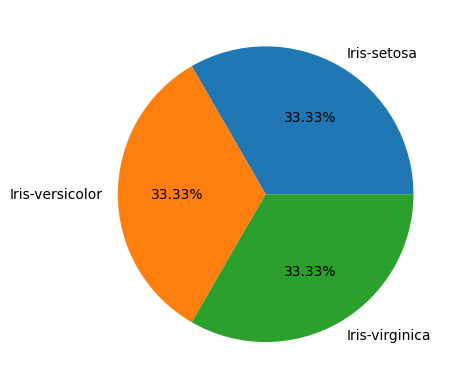

In [8]:
#plt.pie(df_data['class'].value_counts(), labels=df_data['class'].unique(), autopct='%.2f%%')
plt.pie(df_data['class'].value_counts(),labels=df_data['class'].value_counts().index , autopct='%.2f%%')

### **Agrupación y conteo**

- **groupby(['sepal_lenght', 'class']): ** Toma la tabla original y la agrupa usando dos "llaves". Junta todas las flores que tengan exactamente el mismo largo de sépalo y que sean de la misma especie.
- **.size():** Cuenta cuántos registros quedaron dentro de cada uno de esos grupos

- **.reset_index(name= 'sepal_class'):** Cuando se usa groupby, Pandas cambia la forma de la tabla y la vuelve difícil de leer. **reset_index** la vuelve a convertir en una tabla normal y plana, y **name='sepal_class'** le pone ese nombre a la nueva columna que contiene el conteo que se acaba de hacer.

#### **Gráfico de barras múltiples:**
 - **data = dfg:** Le dice a Seaborn que no use la tabla original, sino la tabla agrupada que se creó arriba.
 - **x = 'sepal_lenght':** En el eje horizontal pone las diferentes medidas del sépalo
 - **y = 'sepal_class':** En el eje vertical determina la altura de la barra (el conteo que se hizo).
 - **hue = 'class':**  hue (matiz/color) hace que Seaborn divida automáticamente las barras por colores según la especie de flor y crea una leyenda a un lado.


<Axes: xlabel='sepal_lenght', ylabel='sepal_class'>

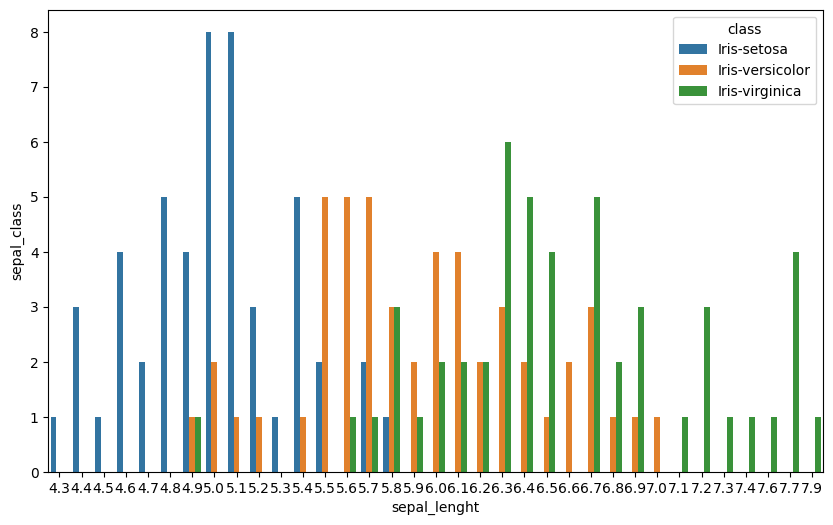

In [9]:
#Llaves para las duplas
dfg = df_data.groupby(['sepal_lenght', 'class']).size().reset_index(name= 'sepal_class')
plt.figure(figsize=(10, 6))

#hue = un asistente
sns.barplot(x = 'sepal_lenght', y = 'sepal_class', hue = 'class', data = dfg)


**Interpretación de los Patrones**
- Patrón 1 (Flores pequeñas - Color Azul): La especie Iris-setosa se agrupa claramente a la izquierda de la gráfica. Sus sépalos miden entre 4.3 y 5.8 centímetros aproximadamente. Hay picos muy altos en 5.0 y 5.1 cm. Conclusión: Si encontramos una flor con un sépalo menor a 5.0 cm, hay una altísima probabilidad de que sea una Iris-setosa.

- Patrón 2 (Flores medianas - Color Naranja): La especie Iris-versicolor se ubica en el centro de la gráfica, predominando en longitudes entre 5.5 y 6.7 cm. Se mezcla un poco con las azules al principio y con las verdes al final.

- Patrón 3 (Flores grandes - Color Verde): La especie Iris-virginica domina la parte derecha de la gráfica. Son las flores con los sépalos más largos, empezando a destacar desde los 6.3 cm y llegando hasta los 7.9 cm. Conclusión: Si una flor tiene un sépalo de más de 7.1 cm, es casi seguro que es una Iris-virginica.



### **Generación de la matriz de gráficos**
- **sns.pairplot(df_data):** Le pasa todo el DataFrame completo. Seaborn buscará automáticamente cuáles columnas son números y las cruzará todas contra todas.
​
- **hue = 'class':** Como ya vimos, esto colorea los puntos basándose en la categoría (la especie de la flor).
- **plot_kws={'alpha': 0.6}:** Es un efecto visual avanzado. **alpha** controla la transparencia de los puntos (va de 0.0 a 1.0). Al ponerlo en 0.6, los puntos se vuelven un poco transparentes. Esto es importante porque cuando hay muchos puntos apilados unos sobre otros, la transparencia permite ver las áreas más densas (más oscuras) en lugar de ver solo una mancha de color.

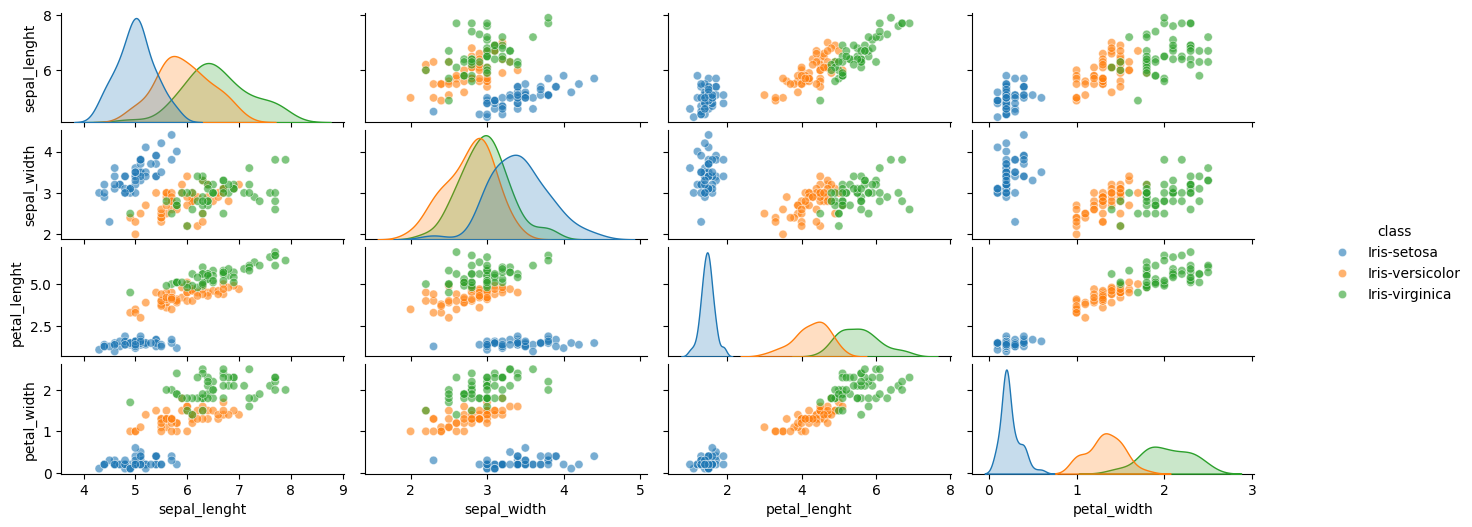

In [10]:
grafico = sns.pairplot(df_data, hue = 'class', plot_kws={'alpha': 0.6})
grafico.fig.set_size_inches(15, 5)

*Con mirar la diagonal, sabemos que las variables del pétalo (petal_lenght y petal_width) son excelentes para identificar a la Iris-setosa. Si el pétalo es muy pequeño, es Setosa con un 100% de seguridad. Las variables del sépalo no son tan buenas porque las tres montañas de colores se sobreponen mucho.*

*Para ahorrar tiempo y cómputo, se podría desechar las columnas de los sépalos y usar únicamente el largo y ancho del pétalo*




### **Filtrado por tipo de dato:**
 -**df_data.select_dtypes(...):** Es una función de Pandas que devuelve un subconjunto de tu tabla basándose en el tipo de dato de las columnas.

- **include=['object']:** Le dice a Pandas qué buscar. En Pandas, el texto  se clasifica bajo el tipo de dato object. Así que esto trae solo las columnas que estén llenas de texto.
​
- **.columns:** Del resultado anterior (que es una tabla), extrae únicamente los títulos o nombres de las columnas.
​

**list(...):** Convierte esos nombres en una lista estándar de Python (ej. ['columna1', 'columna2']) para que sea fácil iterar sobre ella después.

- **categorical = :** Guarda esa lista final en una variable llamada categorical.


In [11]:
categorical = list(df_data.select_dtypes(include=['object']).columns)
print(categorical)

['class']


### **Resumen estadístico**
- Esta instrucción genera un resumen estadístico del DataFrame completo.

*Por defecto, describe() muestra sobre todo columnas numéricas, pero al usar include='all', Pandas también incluye las columnas categóricas o de texto en el resumen.*

In [12]:
#describe por defecto no muestra categoricas
df_data.describe(include='all') #imprime la categoricas

,sepal_lenght,sepal_width,petal_lenght,petal_width,class
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.054000,3.758667,1.198667,NaN
std,0.828066,0.433594,1.764420,0.763161,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


- ***(count)*** *tiene 150 registros en total. Como ningún número baja de 150, se confirma que no hay valores nulos o vacíos en todo el archivo. Los datos están completos.*
- ***unique, top, freq*** *En las columnas numéricas aparece NaN (Not a Number), lo cual es normal porque estas métricas son exclusivas para texto. Solo la columna class tiene datos.*

- ***mean, std*** *mean es el promedio (la media) y std es la desviación estándar (qué tan variados o dispersos están los datos)*

- ***min, 25%, 50%, 75%, max*** *Muestra el valor más bajo, los cortes porcentuales (percentiles) y el valor más alto de cada columna numérica.*

*Esta tabla describe() confirma que el dataset Iris es de una calidad excepcional: no tiene datos nulos (count uniforme), no tiene valores atípicos absurdos (min y max lógicos) y las distribuciones numéricas son estables.*

### **Análsis de Correlación**
- La función **.phik_matrix()** pertenece a la librería Phik. Escanea todo el dataset y calcula la correlación entre absolutamente todas las variables, sean texto (especie) o números (medidas).

  *Guarda en la variable corre_mat una tabla de 5x5 llena de números decimales entre 0 y 1.*

- **cma = sns.diverging_palette(230,10, as_cmap=True)** Usa Seaborn para crear una regla de colores personalizada. Los números 230 y 10 son ángulos en el círculo cromático que representan azul y rojo. as_cmap=True lo convierte en un "Color Map" continuo.

#### **Dibujo de la matriz**
- **plot_correlation_matrix():** Esta es la función especial de Phik que se importó para dibujar.
- **corre_mat.values, x_labels, y_labels:**  pasa los números calculados, y los nombres de las columnas y filas para ponerlos en los bordes del gráfico.

- **vmin=0, vmax=1:** Establece los límites de la barra de color. Como Phik arroja resultados entre 0 (sin correlación) y 1 (correlación perfecta), forzamos a que el color pálido sea 0 y el color más intenso sea 1.



interval columns not set, guessing: ['sepal_lenght', 'sepal_width', 'petal_lenght', 'petal_width']


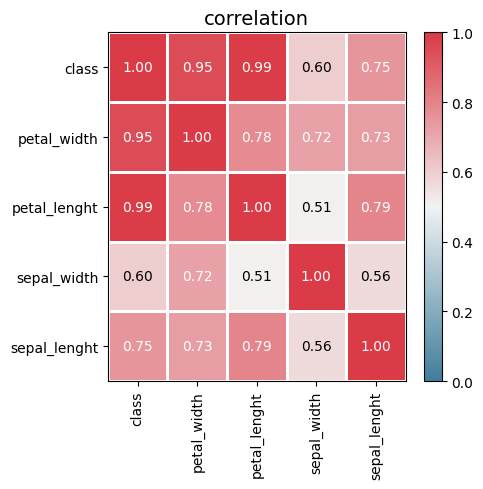

In [13]:
# Análisis de correlación
corre_mat = df_data.phik_matrix()
cma = sns.diverging_palette(230,10, as_cmap=True)
plot_correlation_matrix(corre_mat.values, x_labels = corre_mat.columns, y_labels = corre_mat.index, vmax=1, vmin=0, color_map= cma, figsize=(5,5))
#

*En este dataset, el objetivo ( es la columna class. Así que la atención debe ir directamente a la primera fila o a la primera columna.*

- Pétalo (petal_lenght y petal_width): cuando se cruza la fila class con la columna petal_lenght, se ve un rojo intenso con un número de 0.99. Con petal_width es de 0.95
- Sépalo (sepal_lenght y sepal_width): La correlación con class cae a 0.75 y 0.60 respectivamente. Estas variables ayudan, pero no son tan buenas separando las especies.

El cruce entre petal_width y petal_lenght (fila 2, columna 3). Tienen un valor alto de 0.78.
- Cuando dos variables independientes tienen una correlación muy alta entre sí, sufren de lo que en Machine Learning se llama "Multicolinealidad". Significa que están dando la misma información duplicada. A medida que el pétalo se hace más largo, casi siempre se hace más ancho proporcionalmente.
- En un modelo de regresión complejo, tener columnas "gemelas" confunde al algoritmo y gasta memoria. Una buena práctica de Data Cleaning/Engineering sería eliminar una de las dos, porque con una sola ya le das suficiente información al modelo.




## **Preprocesamiento**
### **Extracción de los datos puros:**

- La propiedad **.values** de Pandas toma toda la tabla df_data, elimina los nombres de las columnas y los índices, y devuelve un arreglo de Numpy que contiene solo la información interna
- La función estándar de Python type() dice qué tipo de objeto se obtine. En lugar de devolver pandas.core.frame.DataFrame (que era lo que tenías antes), ahora devolverá numpy.ndarray. Esto significa "N-Dimensional Array" (Arreglo de N dimensiones)

- np.ndim(dataset): Llama a la librería Numpy (np) y usa la función .ndim() (Number of Dimensions) sobre la nueva matriz para ver que tan profunda es.



In [49]:
dataset = df_data.values
type(dataset)
np.ndim(dataset) #matriz

2

In [15]:
dataset

array([[5.1, 3.5, 1.4, 0.2, 'Iris-setosa'],
       [4.9, 3.0, 1.4, 0.2, 'Iris-setosa'],
       [4.7, 3.2, 1.3, 0.2, 'Iris-setosa'],
       [4.6, 3.1, 1.5, 0.2, 'Iris-setosa'],
       [5.0, 3.6, 1.4, 0.2, 'Iris-setosa'],
       [5.4, 3.9, 1.7, 0.4, 'Iris-setosa'],
       [4.6, 3.4, 1.4, 0.3, 'Iris-setosa'],
       [5.0, 3.4, 1.5, 0.2, 'Iris-setosa'],
       [4.4, 2.9, 1.4, 0.2, 'Iris-setosa'],
       [4.9, 3.1, 1.5, 0.1, 'Iris-setosa'],
       [5.4, 3.7, 1.5, 0.2, 'Iris-setosa'],
       [4.8, 3.4, 1.6, 0.2, 'Iris-setosa'],
       [4.8, 3.0, 1.4, 0.1, 'Iris-setosa'],
       [4.3, 3.0, 1.1, 0.1, 'Iris-setosa'],
       [5.8, 4.0, 1.2, 0.2, 'Iris-setosa'],
       [5.7, 4.4, 1.5, 0.4, 'Iris-setosa'],
       [5.4, 3.9, 1.3, 0.4, 'Iris-setosa'],
       [5.1, 3.5, 1.4, 0.3, 'Iris-setosa'],
       [5.7, 3.8, 1.7, 0.3, 'Iris-setosa'],
       [5.1, 3.8, 1.5, 0.3, 'Iris-setosa'],
       [5.4, 3.4, 1.7, 0.2, 'Iris-setosa'],
       [5.1, 3.7, 1.5, 0.4, 'Iris-setosa'],
       [4.6, 3.6, 1.0, 0.2, 'Iri

### **Separar entradas y salida esperada**
- **x = dataset[:,0:-1]** ":" en la parte de las filas = toma todas las filas. "0:-1" en la parte de las columnas = toma desde la columna 0 hasta la penúltima, sin incluir la última.
x guarda todas las columnas de entrada, es decir, las variables independientes.

- **y = dataset[:,-1]** ":" = toma todas las filas. "-1" = toma la última columna. y guarda la variable dependiente

In [50]:
x= dataset[:,0:-1] #separar variables independientes de las dependientes
y = dataset[:,-1] # ponerla siempre al final /consultar como mover una columna con pandas al final

*Si se quisiera dejar class al final de forma explícita, sería así*


```
df_data = df_data[[col for col in df_data.columns if col != 'class'] + ['class']]
```
- toma todas las columnas menos class;

- luego agrega class al final.


Se llama a la librería Numpy que usa la función .shapesobre la variable x. Esta función no muestra los datos por dentro, sino que devuelve el tamaño de la matriz en formato (filas, columnas).

In [17]:
print(x)
np.shape(x)

[[5.1 3.5 1.4 0.2]
 [4.9 3.0 1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.0 3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.0 3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.0 1.4 0.1]
 [4.3 3.0 1.1 0.1]
 [5.8 4.0 1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.0 0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.0 3.0 1.6 0.2]
 [5.0 3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.0 3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [4.4 3.0 1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.0 3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.0 3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.0 1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.0 3.3 1.4 0.2]
 [7.0 3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

(150, 4)

- Se Usa la misma función shape de Numpy para medir el tamaño matemático de esta nueva variable y, y luego lo imprime.

In [18]:
print(y)
print(np.shape(y))  #


['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor

### **Ingeniería de características**

- Esta línea crea una instancia de la herramienta **LabelEncoder** que pertenece a la librería scikit-learn. Esta herramienta permitetraducir texto a números. Toma cada categoría única que encuentre y le asigna un número entero secuencial empezando desde cero.




In [19]:
le = preprocessing.LabelEncoder()


- La función .fit() (que en español significa "ajustar" o "entrenar") es la encargada de hacer que la herramienta aprenda de los datos. Al pasarle la variable y (que contiene las etiquetas de las flores como 'Iris-setosa'), el LabelEncoder escanea toda esa lista para identificar y memorizar cuáles son todas las categorías únicas que existen en el dataset.



In [20]:
le.fit(y)

LabelEncoder()

- Al llamar al atributo .classes_ (tiene un guion bajo al final, esto es una convención en Scikit-Learn para atributos que se crean después de hacer un fit), se le pide al LabelEncoder que muestre el "diccionario" exacto que acaba de aprender y memorizar en el paso anterior

In [21]:
le.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

- La función .transform() toma la lista de palabras originales (y) y, usando el diccionario interno que el LabelEncoder memorizó durante el .fit(), reemplaza cada palabra por su número correspondiente. Luego, guarda este nuevo arreglo de números puros en una nueva variable llamada y_int (que significa "y en formato integer" o entero).

In [22]:
y_int = le.transform(y)


- La función .inverse_transform() (transformación inversa) toma los números puros que se crearon en el paso anterior (y_int) y los vuelve a traducir a las palabras originales de texto.

In [23]:
le.inverse_transform(y_int)

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versic

## **Entrenamiento de los modelos**
#### **Primer split**
- Se divide el dataset original en dos partes:
  - X_train y y_train: datos que quedan para seguir trabajando.
  - X_val y y_val: pequeño subconjunto para validación.

##### ***¿Qué significa cada parámetro?***
- test_size=0.05
Reserva el 5% del dataset para validación.

- random_state=3
Fija una semilla aleatoria para que la división salga igual cada vez que se ejecute el código.
Eso es útil porque permite reproducir resultados.

- stratify=y_int
Hace que la división conserve la misma proporción de clases en ambos subconjuntos.
  
  *Por ejemplo, si en el dataset original cada especie representa un tercio de los datos, entonces en validación y entrenamiento también se conservará aproximadamente esa proporción.*

#### **Segundo Split**
- Se toma el conjunto grande que sobró del primer split y se vuelve a dividir en dos:
    - X_train, y_train: entrenamiento final.
    - X_test, y_test: prueba final.

##### **Qué significa cada parámetro**
- X_train, y_train
Ya no se usa el dataset completo, sino solo el bloque que quedó después de separar validación.

- test_size=0.15
Aquí se toma el 15% de ese conjunto restante para prueba.

  *Nota: no significa 15% del total original, sino 15% del 95% que quedó después del primer split.*


In [54]:
# Primer split: separar validación (5%)
X_train, X_val, y_train, y_val = train_test_split(
    x,
    y_int,
    test_size=0.05,
    random_state=3,
    stratify=y_int
) # y ya codificada, 5% de los datos para la validación, se extraen de forma aleatoria, stratify --- misma proporción de clases, variable dependiente-

# Segundo split: separar test (15%) desde el conjunto de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=3,
    stratify=y_train
)


- print(np.unique(y, return_counts=True)): En el bloque anterior se usa stratify para obligar al programa a mantener la misma proporción de especies de flores en todos los recortes. Estas cuatro líneas de código sirven para verificar que el código train_test_split cumplió

In [57]:
print(np.unique(y, return_counts=True))
print(np.unique(y_train, return_counts=True))
print(np.unique(y_val, return_counts=True))
print(np.unique(y_test, return_counts=True))


(array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object), array([50, 50, 50]))
(array([0, 1, 2]), array([40, 40, 40]))
(array([0, 1, 2]), array([3, 2, 3]))
(array([0, 1, 2]), array([7, 8, 7]))


### **Instanciación del Modelo**
- Esta línea "crea" el modelo KNN y establece sus hiperparámetros.

#### **Interpretación de los hiperparámetros:**

 - n_neighbors=5: configura que cuando llegue una flor nueva,  se busque a sus 5 vecinas más cercanas en el gráfico para tomar la decisión. Si de esas 5 vecinas, 3 son Setosa y 2 son Versicolor, el modelo decidirá que la nueva flor es Setosa por mayoría de votos.

 - metric='manhattan': Define la fórmula matemática que usará para medir la "distancia" entre las flores.
 - weights='uniform': Le dice al modelo que el voto de los 5 vecinos vale exactamente lo mismo. No importa su distancia; el voto vale "1"

### **Entrenamiento del Modelo**
- El método .fit() ejecuta el entrenamiento real. Toma la matriz de datos de entrada (X_train con las medidas numéricas) y el vector de respuestas correctas (y_train con los códigos 0, 1 y 2).


In [59]:
knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan', weights= 'uniform' )

knn.fit(X_train, y_train)

KNeighborsClassifier(metric='manhattan')

- La función .score() es un método de conveniencia (un atajo) que hace dos cosas internamente en una sola línea de código:

  - Predice: Toma la matriz de entrada (X) y la pasa por el modelo para generar las predicciones (y_pred).

  - Califica: Compara esas predicciones con las respuestas correctas (y_train o y_test) y calcula qué porcentaje de aciertos tuvo el modelo.


 - La primera línea evalúa qué tan bien le va al modelo con los mismos datos que usó para estudiar (Datos de Entrenamiento).
  - La segunda línea evalúa qué tan bien le va con datos completamente nuevos que nunca ha visto (Datos de Prueba).


In [29]:
train_acc= knn.score(X_train, y_train)
test_acc = knn.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.9833333333333333
0.9090909090909091


- 0.9833... (Es decir, 98.3% de precisión)

  Cuando se hizo el examen al modelo utilizando las mismas flores que había usado para estudiar (el conjunto X_train), acertó casi todas. Se equivocó tal vez en una o dos flores de todo el grupo.
- 0.9090... (Es decir, 90.9% de precisión)

  Cuando se sacó el grupo de flores nuevas (el conjunto X_test) y se le pidió al modelo que las clasificara, su rendimiento bajó al 90.9%.




- Ambas líneas simplemente muestran el contenido de dos de las matrices X_test y X_train

In [30]:
print(X_test)
print(X_train)

[[7.7 2.6 6.9 2.3]
 [6.2 2.2 4.5 1.5]
 [7.7 2.8 6.7 2.0]
 [5.9 3.2 4.8 1.8]
 [5.7 2.6 3.5 1.0]
 [6.5 3.0 5.5 1.8]
 [5.7 2.9 4.2 1.3]
 [6.2 2.8 4.8 1.8]
 [7.7 3.0 6.1 2.3]
 [5.0 3.0 1.6 0.2]
 [6.1 2.9 4.7 1.4]
 [6.3 2.5 4.9 1.5]
 [5.5 3.5 1.3 0.2]
 [5.0 3.5 1.3 0.3]
 [7.3 2.9 6.3 1.8]
 [4.6 3.4 1.4 0.3]
 [4.6 3.2 1.4 0.2]
 [6.0 2.2 4.0 1.0]
 [5.2 4.1 1.5 0.1]
 [5.1 3.5 1.4 0.3]
 [5.6 2.5 3.9 1.1]
 [6.1 2.6 5.6 1.4]]
[[6.8 3.2 5.9 2.3]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [7.2 3.6 6.1 2.5]
 [6.0 3.0 4.8 1.8]
 [7.9 3.8 6.4 2.0]
 [5.8 2.7 4.1 1.0]
 [5.5 4.2 1.4 0.2]
 [5.1 3.3 1.7 0.5]
 [5.4 3.9 1.7 0.4]
 [5.9 3.0 5.1 1.8]
 [6.1 2.8 4.0 1.3]
 [6.3 2.9 5.6 1.8]
 [6.3 2.5 5.0 1.9]
 [5.8 2.7 5.1 1.9]
 [5.0 3.2 1.2 0.2]
 [5.0 3.3 1.4 0.2]
 [5.1 3.7 1.5 0.4]
 [5.6 3.0 4.5 1.5]
 [7.2 3.2 6.0 1.8]
 [6.3 2.8 5.1 1.5]
 [6.5 2.8 4.6 1.5]
 [4.9 3.1 1.5 0.1]
 [4.8 3.0 1.4 0.1]
 [4.9 3.1 1.5 0.1]
 [6.1 2.8 4.7 1.2]
 [5.7 3.0 4.2 1.2]
 [6.6 2.9 4.6 1.3]
 [6.8 2.8 4.8 1.4]
 [6.9 3.1 5.4 2.1]
 [5.1 3.4 1

### Modelos de Data Quality

- y_pred = knn.predict(X_test): oma los datos numéricos de prueba (X_test), que el modelo nunca ha visto, y los pasa por el algoritmo KNN ya entrenado para que adivine a qué especie pertenece cada flor.

- mc = confusion_matrix(y_test, y_pred): Invoca la función confusion_matrix que  se importo antes. Le pasa dos listas: primero la lista de respuestas verdaderas (y_test), y segundo la lista de las respuestas que el modelo adivinó (y_pred).


In [31]:
y_pred =knn.predict(X_test)
mc = confusion_matrix(y_test, y_pred)
print(y_test)
print(y_pred)
print(mc)



[2 1 2 1 1 2 1 2 2 0 1 1 0 0 2 0 0 1 0 0 1 2]
[2 1 2 2 1 2 1 2 2 0 1 2 0 0 2 0 0 1 0 0 1 2]
[[7 0 0]
 [0 6 2]
 [0 0 7]]


- y_train_pred = knn.predict(x): Aquí se le pidió al modelo que hiciera predicciones usando la matriz original completa x (todas las 150 flores).

- print(classification_report(...)): Luego, usa la función de Scikit-Learn que compara esas predicciones (y_train_pred) contra la realidad completa (y_int) y genera un reporte estadístico en forma de tabla.

    **Nota importante sobre buenas prácticas:** Profesionalmente, el classification_report siempre debe hacerse sobre el grupo de prueba X_test, no sobre el x completo, para ver el rendimiento real sin sobreajuste. Aquí el profesor lo hizo sobre x a modo de demostración pedagógica general).

In [32]:
y_train_pred = knn.predict(x)
print(classification_report(y_int, y_train_pred)) # Consultar precisión y recall

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.98      0.94      0.96        50
           2       0.94      0.98      0.96        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



1. **Precision (Precisión)**

    ¿Qué responde?: "De todas las veces que mi modelo predijo que  sería una Versicolor, ¿cuántas veces tuvo razón?"

    Mide la calidad de los Aciertos Positivos del modelo. Te dice qué tan confiable es cuando afirma algo.

    Ejemplo en la tabla: Si la clase 1 (Versicolor) tiene un precision de 0.98, significa que cuando el modelo predice Versicolor, acierta el 98% de las veces. El 2% restante se lo atribuyó a Versicolor, pero en realidad eran de otra clase (Falsos Positivos).
2. **Recall (Exhaustividad o Sensibilidad)**

    ¿Qué responde?: "De todas las flores Versicolor que existían realmente en el mundo, ¿cuántas logró encontrar y clasificar mi modelo?"

    Mide la capacidad de rastreo del modelo. Dice si se le están "escapando" casos reales.

    Ejemplo en la tabla: Si la clase 1 tiene un recall de 0.94, significa que el modelo logró encontrar al 94% de las Versicolores reales, pero hubo un 6% de Versicolores que pasaron por el modelo y las clasificó mal (Falsos Negativos).

3.  **F1-Score (El equilibrio)**

    Es una calificación general que combina el Precision y el Recall en un solo número haciendo un promedio armónico.


    Por qué importa: A veces un modelo tiene 100% de Precisión pero 10% de Recall (es decir, es muy cuidadoso al hablar, pero se le escapan casi todos los casos). El F1-score castiga esos desequilibrios. Si el F1-Score es alto (cercano a 1.00), significa que el modelo es tanto preciso como exhaustivo.


#### Matriz de confusión
 - se utiliza la clase ConfusionMatrixDisplay que importamos antes. Le entrega dos cosas: la matriz numérica cruda (mc) y las etiquetas originales en texto de las flores (display_labels=le.classes_).

 - Se llama al método .plot() para renderizar el dibujo. El parámetro cmap (Color Map) define la paleta de colores. plt.cm.Blues significa que usará diferentes tonos de azul.



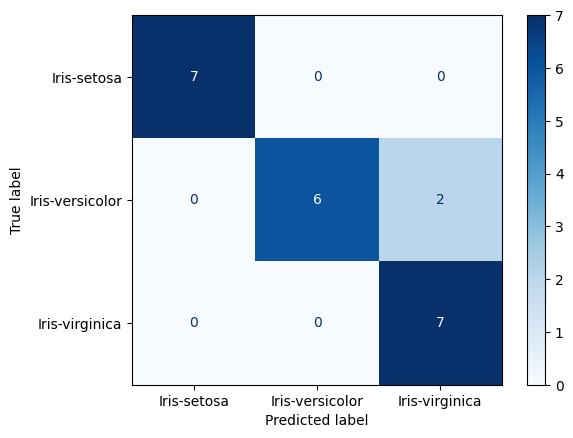

In [33]:
#Matriz de confusión
imagen_matriz = ConfusionMatrixDisplay(mc, display_labels=le.classes_)
imagen_matriz.plot(cmap=plt.cm.Blues)
plt.show()

### **Modelo Naive Bayes Gaussiano**

- gb = GaussianNB(): Crea la herramienta del modelo y la guarda en la variable gb. Nota que aquí no le pasamos parámetros especiales (como el n_neighbors=5 del KNN). Naive Bayes es famoso por ser un algoritmo muy rápido y simple que casi no requiere configuración manual.

- gb.fit(X_train, y_train): Entrena el modelo usando los mismos datos de estudio que usamos para el KNN.

In [64]:

gb= GaussianNB()
gb.fit(X_train, y_train)


GaussianNB()

In [35]:
y_pred = gb.predict(x)
print(classification_report(y_int, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.96      0.95        50
           2       0.96      0.94      0.95        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



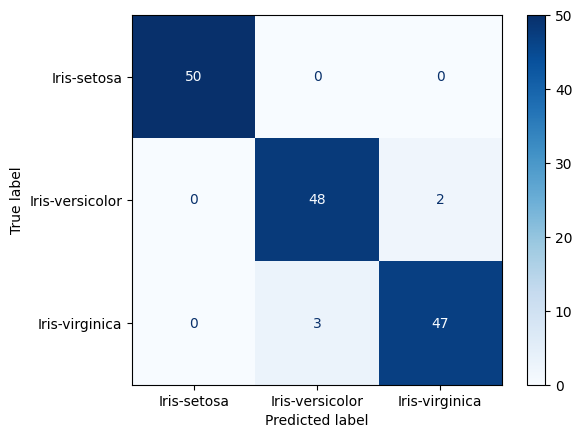

In [36]:
mc= confusion_matrix(y_int, y_pred)
imagen_matriz = ConfusionMatrixDisplay(mc, display_labels=le.classes_)
imagen_matriz.plot(cmap=plt.cm.Blues)
plt.show()

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [38]:
dstree= DecisionTreeClassifier(max_depth=3)
dstree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

- gb = GaussianNB(): Instancia (crea) el modelo de Naive Bayes Gaussiano y lo guarda en la variable gb. A diferencia del KNN, fíjate que aquí los paréntesis están vacíos; este algoritmo casi no necesita que le ajustemos hiperparámetros manuales para funcionar bien.

- gb.fit(X_train, y_train): Inicia el proceso de entrenamiento. El modelo toma la matriz numérica de entrada (X_train) y las etiquetas correctas (y_train) para aprender.

In [39]:
y_pred = dstree.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.88      0.93         8
           2       0.88      1.00      0.93         7

    accuracy                           0.95        22
   macro avg       0.96      0.96      0.96        22
weighted avg       0.96      0.95      0.95        22



#### **Matriz de confusión**


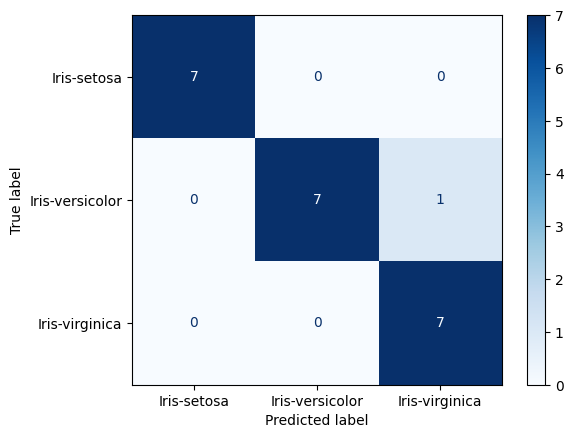

In [66]:

cm = confusion_matrix(y_test, y_pred)
mat = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
mat.plot(cmap= plt.cm.Blues)
plt.show() #Consultar falsos positivos y negativos casos recall, precisión, f1-score

### **Árbol de Decisión (Decision Tree).**
- tree.plot_tree(...): Esta es una función especializada de Scikit-Learn que toma el "cerebro" del modelo matemático de árbol de decisión ya entrenado (dstree) y lo dibuja en pantalla.

- feature_names=df_data.columns: Le pasa los nombres de las columnas originales (sepal_lenght, petal_width, etc.)

[Text(0.4, 0.875, 'petal_lenght <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 40, 40]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'petal_width <= 1.75\ngini = 0.5\nsamples = 80\nvalue = [0, 40, 40]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'petal_lenght <= 4.95\ngini = 0.165\nsamples = 44\nvalue = [0, 40, 4]'),
 Text(0.2, 0.125, 'gini = 0.05\nsamples = 39\nvalue = [0, 38, 1]'),
 Text(0.6, 0.125, 'gini = 0.48\nsamples = 5\nvalue = [0, 2, 3]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 36\nvalue = [0, 0, 36]')]

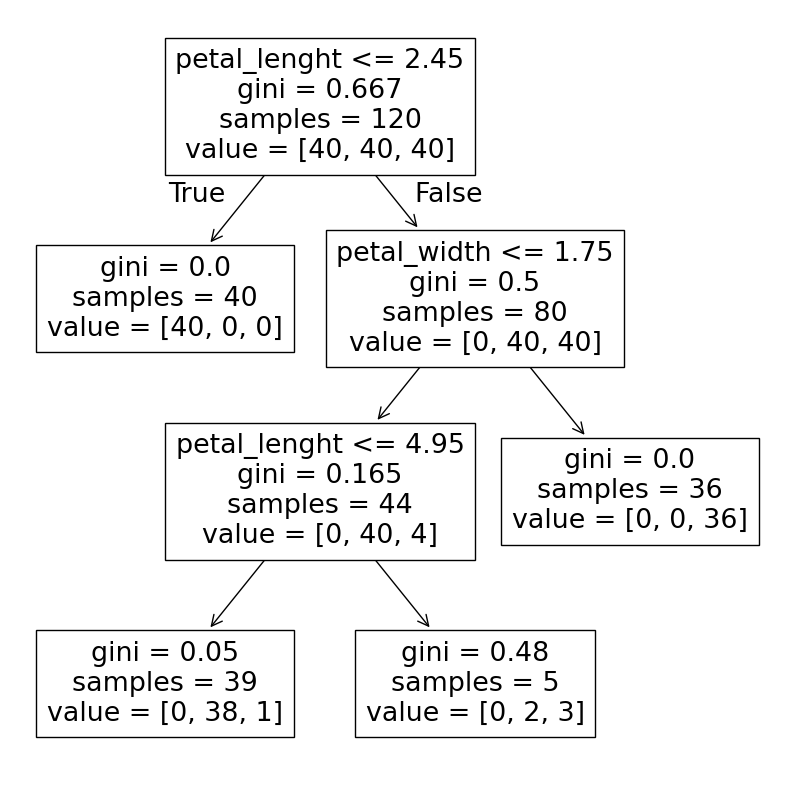

In [41]:
figura= plt.figure(figsize=(10, 10))
tree.plot_tree(dstree, feature_names=df_data.columns)



 ***Lectura del árbol***

- El Nodo Raíz (La regla más importante de todas)
​

  La regla matemática: petal_lenght <= 2.45 (¿El largo del pétalo es menor o igual a 2.45 cm?).

  - samples = 120: Aquí están las 120 flores de entrenamiento completas ( X_train).

  - value = [40, 40, 40]: De esas 120 flores, 40 son Setosa (posición 0), 40 son Versicolor (posición 1) y 40 son Virginica (posición 2).

  - gini = 0.667: Es el índice de "impureza". Un número alto significa que las tres especies están totalmente mezcladas en esta caja. El objetivo del árbol es bajar ese número a cero separándolas.

-  El Camino Izquierdo (Cuando la respuesta es True / Sí)
Sigue la flecha izquierda que dice "True". Llegas a una nueva caja.

    - value = [40, 0, 0]:Esta caja solo tiene 40 flores de la especie 0 (Setosas) y cero de las otras dos.

    - gini = 0.0: El índice de impureza cayó a cero. Esto significa que este grupo es 100% puro.

    *"Si una flor tiene un pétalo de 2.45 cm o menos, es una Iris-setosa con 100% de seguridad. No es necesario hacer más preguntas".* Por eso debajo de esta caja ya no hay más flechas. A esto se le llama un "Nodo Hoja" puro.

-  El Camino Derecho (Cuando la respuesta es False / No)
Regresa a la caja de arriba y ahora baja por la derecha. Llega a una caja donde samples = 80.

    - value = [0, 40, 40]:  el primer número es cero. Las Setosas ya fueron descartadas. Ahora el árbol tiene que aprender a separar las Versicolor contra las Virginicas.
    - La nueva regla: petal_width <= 1.75 (¿El ancho del pétalo es menor a 1.75?).
   - Si la respuesta vuelve a ser falsa (derecha), llega a una caja donde value = [0, 0, 36] y gini = 0.0.

    *"Si el pétalo es largo (>2.45) y además es muy ancho (>1.75), entonces puedo afirmar que es una Iris-virginica con absoluta seguridad".*

### **Máquina de Vectores de Soporte (SVC)**

- svm = SVC(...): Instancia (crea) el modelo con configuraciones muy específicas y lo guarda en la variable svm.

- svm.fit(...): Entrena el modelo usando los datos de entrada (X_train) y las respuestas correctas (y_train).

#### **Explicación de los hiperparámetros**
-  kernel='linear': El kernel es la "forma" de la frontera matemática que el modelo va a dibujar para separar las especies de flores. Al decirle que sea linear, el algoritmo las separará con una linea recta.

- C=10: La "C" es el nivel de severidad. Le dice al modelo qué tanto debe preocuparse por cometer errores de clasificación.
- gamma='scale: gamma define la "zona de influencia" de cada punto de datos.

   *Cuando se usa un kernel lineal, matemáticamente la variable gamma se ignora por completo (solo funciona para kernels curvos como 'rbf' o 'poly')*

In [67]:
svm = SVC(kernel='linear', gamma='scale', C= 10)
svm.fit(X_train, y_train)

SVC(C=10, kernel='linear')

- Se usa la función classification_report para comparar las verdaderas especies de esas flores (y_test) con lo que el modelo SVM creyó que eran (y_pred)

In [44]:
y_pred= svm.predict(X_test)
print(classification_report(y_test, y_pred))
#

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.75      0.86         8
           2       0.78      1.00      0.88         7

    accuracy                           0.91        22
   macro avg       0.93      0.92      0.91        22
weighted avg       0.93      0.91      0.91        22



- Se crean tres listas de Python que contienen los diferentes hiperparámetros que el algoritmo GridSearchCV va a poner a competir entre sí

In [68]:
kernel = ['linear', 'poly', 'rbf', 'sigmoid']
gamma = ['scale', 'auto']
C = [0.1, 10]

##**Configurar la Búsqueda (GridSearchCV)**
- estimator=svm: El modelo que se a pone a prueba es el SVC.

- param_grid=dict(...): se empaquetan las tres listas  (kernel, gamma, C) dentro de un diccionario de Python.


In [47]:
grid_s = GridSearchCV(estimator=svm, param_grid =dict(kernel=kernel, gamma=gamma, C=C))  #Buscar mejores hiperparámetros
grid_s.fit(X_train, y_train)
print(f"Los parámetros ideales para SVM son {grid_s.best_params_} {grid_s.best_score_}")

Los parámetros ideales para SVM son {'C': 0.1, 'gamma': 'scale', 'kernel': 'poly'} 0.9916666666666668


Para knn


In [48]:
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(estimator=knn, param_grid = param_grid_knn)
grid_knn.fit(X_train, y_train)
print(f"Los parámetros ideales para KNN son {grid_knn.best_params_} {grid_knn.best_score_}")

Los parámetros ideales para KNN son {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'} 0.9833333333333334
